# 04. Artist composition vs Top 1% concentration

3차까지: Length / Followers / Edits는 Top1 차이를 **거의 설명하지 못함**. 짧은 플리 착시도 아님.

이번 질문:

> **Top 1% 인기곡 중심 Playlist와 그렇지 않은 Playlist는 Artist 구성도 다른가?**

순서:

1. Artist Diversity (`unique_artist_ratio`)
2. 관계가 있으면 Length 통제
3. 관계가 남으면 repetition (`top_artist_share`, `artist_entropy`)
4. `num_tracks >= 20` sensitivity

선행: `python -m src.aggregate --composition-only` (unique_artist_ratio / top_artist_share 포함)

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

HERE = Path.cwd()
if (HERE / "data" / "processed").exists():
    ROOT = HERE
elif (HERE.parent / "data" / "processed").exists():
    ROOT = HERE.parent
else:
    ROOT = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

Y = "top_1pct_ratio"
MIN_TRACKS_SENS = 20

In [14]:
comp = pd.read_parquet(PROCESSED / "playlist_composition.parquet")
meta = pd.read_parquet(
    PROCESSED / "playlist_meta.parquet",
    columns=["pid", "num_tracks", "num_artists"],
)
df = comp.merge(meta, on="pid", how="inner")

if "unique_artist_ratio" not in df.columns:
    df["unique_artist_ratio"] = df["n_unique_artists"] / df["n_items"].replace(0, np.nan)
    print("unique_artist_ratio: derived from n_unique_artists / n_items")
if "top_artist_share" not in df.columns:
    print("경고: top_artist_share 없음. `python -m src.aggregate --composition-only` 재실행 필요.")

df["len_bin"] = pd.cut(
    df["num_tracks"],
    bins=[0, 20, 50, 100, 150, 400],
    labels=["1-20", "21-50", "51-100", "101-150", "151+"],
    right=True,
)
df["top1_bin"] = pd.qcut(df[Y], q=5, duplicates="drop")

print(f"n={len(df):,}")
df[[Y, "unique_artist_ratio", "artist_entropy"] + (
    ["top_artist_share"] if "top_artist_share" in df.columns else []
)].describe().round(3)

n=1,000,000


,top_1pct_ratio,unique_artist_ratio,artist_entropy,top_artist_share
count,1000000.000,1000000.000,1000000.000,1000000.000
mean,0.672,0.643,4.472,0.158
std,0.287,0.227,1.285,0.150
min,0.000,0.012,0.076,0.004
25%,0.489,0.500,3.700,0.070
50%,0.759,0.670,4.590,0.111
75%,0.909,0.818,5.388,0.185
max,1.000,1.000,7.890,0.992


In [15]:
def describe_col(frame: pd.DataFrame, col: str) -> pd.DataFrame:
    def _one(s: pd.Series) -> pd.Series:
        s = s.dropna()
        return pd.Series({
            "n": len(s),
            "mean": s.mean(),
            "p50": s.median(),
            "p25": s.quantile(0.25),
            "p75": s.quantile(0.75),
            "iqr": s.quantile(0.75) - s.quantile(0.25),
        })
    return frame.groupby("top1_bin", observed=True)[col].apply(_one).unstack()


def spearman(frame: pd.DataFrame, x: str, y: str = Y) -> float:
    return frame[[x, y]].dropna().corr(method="spearman").iloc[0, 1]

## A. Artist Diversity

`unique_artist_ratio = unique artists / tracks`

질문: **Top1 concentration이 높은 플리는 Artist가 더 단조로운가?**

In [16]:
print(f"Spearman({Y}, unique_artist_ratio) = {spearman(df, 'unique_artist_ratio'):.4f}")
describe_col(df, "unique_artist_ratio").round(3)

Spearman(top_1pct_ratio, unique_artist_ratio) = 0.1042


,n,mean,p50,p25,p75,iqr
top1_bin,,,,,,
"(-0.001, 0.407]",200281.0,0.573,0.590,0.346,0.818,0.472
"(0.407, 0.667]",201831.0,0.653,0.684,0.494,0.840,0.346
"(0.667, 0.829]",198053.0,0.659,0.682,0.524,0.814,0.290
"(0.829, 0.933]",203659.0,0.662,0.680,0.536,0.805,0.269
"(0.933, 1.0]",196176.0,0.670,0.690,0.551,0.812,0.261


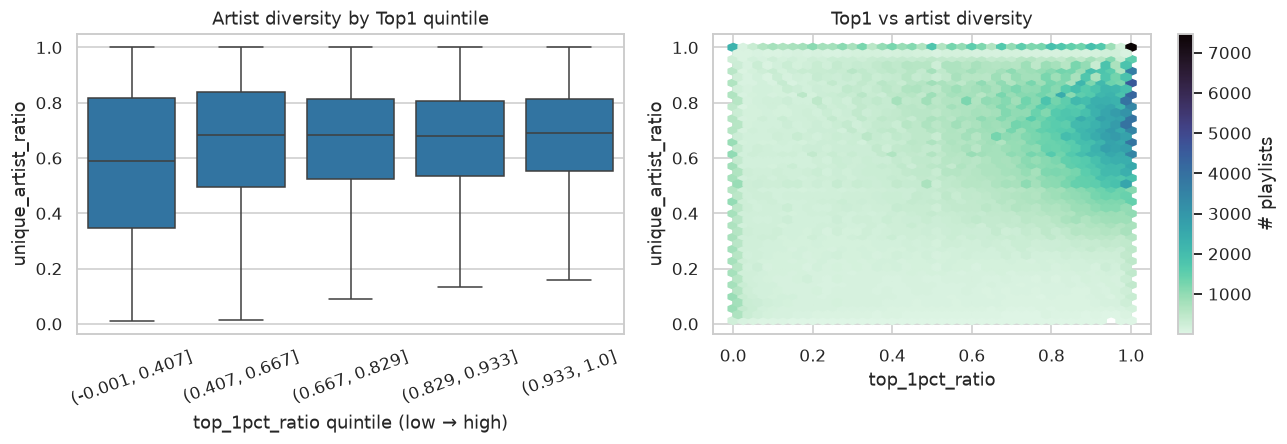

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.boxplot(
    data=df, x="top1_bin", y="unique_artist_ratio",
    showfliers=False, ax=axes[0], color="#1f77b4",
)
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_xlabel("top_1pct_ratio quintile (low → high)")
axes[0].set_title("Artist diversity by Top1 quintile")

hb = axes[1].hexbin(
    df[Y], df["unique_artist_ratio"],
    gridsize=40, cmap="mako_r", mincnt=1,
)
axes[1].set_xlabel("top_1pct_ratio")
axes[1].set_ylabel("unique_artist_ratio")
axes[1].set_title("Top1 vs artist diversity")
fig.colorbar(hb, ax=axes[1], label="# playlists")
fig.tight_layout()

**판단:**
- 관계가 뚜렷하면 (예: Top1↑ → diversity↓) → B에서 Length 통제
- 거의 평평하면 → Popularity concentration과 Artist composition은 **다른 축**. C를 깊게 안 파고 sensitivity만 본 뒤 추천 단계 검토

## B. Length 통제

짧은 플리는 unique artist ratio가 구조적으로 흔들릴 수 있다.
같은 길이 안에서도 Top1↔diversity가 남는가?

In [18]:
print(f"Spearman(unique_artist_ratio, num_tracks) = {spearman(df, 'unique_artist_ratio', 'num_tracks'):.4f}")

pivot = (
    df.groupby(["len_bin", "top1_bin"], observed=True)["unique_artist_ratio"]
    .median()
    .unstack("top1_bin")
)
pivot.round(3)

Spearman(unique_artist_ratio, num_tracks) = -0.4232


top1_bin,"(-0.001, 0.407]","(0.407, 0.667]","(0.667, 0.829]","(0.829, 0.933]","(0.933, 1.0]"
len_bin,,,,,
1-20,0.800,0.850,0.842,0.833,0.818
21-50,0.646,0.741,0.744,0.739,0.727
51-100,0.510,0.641,0.658,0.659,0.654
101-150,0.419,0.570,0.587,0.588,0.589
151+,0.340,0.506,0.529,0.529,0.534


,len_bin,n,spearman_top1_diversity
0,1-20,178744,0.0167
1,21-50,333702,0.0691
2,51-100,271072,0.1450
3,101-150,120954,0.1798
4,151+,95528,0.2279


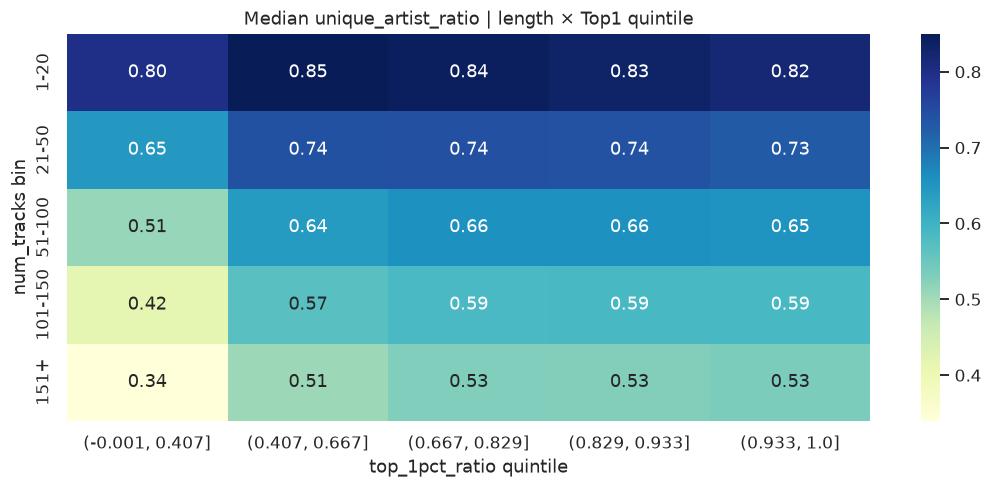

In [19]:
fig, ax = plt.subplots(figsize=(10, 4.6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("Median unique_artist_ratio | length × Top1 quintile")
ax.set_xlabel("top_1pct_ratio quintile")
ax.set_ylabel("num_tracks bin")
fig.tight_layout()

rows = []
for lab, g in df.groupby("len_bin", observed=True):
    rows.append({
        "len_bin": lab,
        "n": len(g),
        "spearman_top1_diversity": spearman(g, "unique_artist_ratio"),
    })
pd.DataFrame(rows).round(4)

## C. Artist repetition (관계가 남을 때만 해석을 깊게)

- `top_artist_share`: 가장 많이 나온 Artist가 플리 곡의 몇 %인가
- `artist_entropy`: 아티스트 분포의 엔트로피 (높을수록 고름)

A/B에서 관계가 약하면 숫자만 확인하고 메인 스토리로 밀지 않는다.

In [20]:
print(f"Spearman({Y}, artist_entropy) = {spearman(df, 'artist_entropy'):.4f}")
if "top_artist_share" in df.columns:
    print(f"Spearman({Y}, top_artist_share) = {spearman(df, 'top_artist_share'):.4f}")

describe_col(df, "artist_entropy").round(3)

Spearman(top_1pct_ratio, artist_entropy) = 0.1157
Spearman(top_1pct_ratio, top_artist_share) = -0.1120


,n,mean,p50,p25,p75,iqr
top1_bin,,,,,,
"(-0.001, 0.407]",200281.0,3.965,4.056,3.039,4.976,1.937
"(0.407, 0.667]",201831.0,4.530,4.607,3.741,5.434,1.692
"(0.667, 0.829]",198053.0,4.711,4.798,4.000,5.545,1.546
"(0.829, 0.933]",203659.0,4.702,4.812,4.003,5.528,1.525
"(0.933, 1.0]",196176.0,4.451,4.584,3.755,5.317,1.561


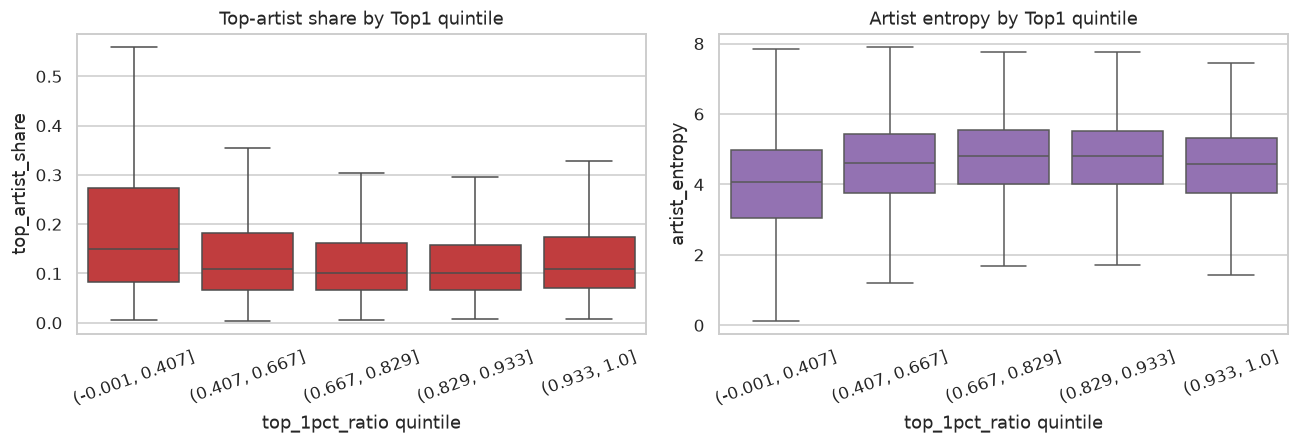

In [21]:
if "top_artist_share" not in df.columns:
    print("top_artist_share 없음 — composition 재집계 후 실행")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    sns.boxplot(
        data=df, x="top1_bin", y="top_artist_share",
        showfliers=False, ax=axes[0], color="#d62728",
    )
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].set_title("Top-artist share by Top1 quintile")
    axes[0].set_xlabel("top_1pct_ratio quintile")

    sns.boxplot(
        data=df, x="top1_bin", y="artist_entropy",
        showfliers=False, ax=axes[1], color="#9467bd",
    )
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].set_title("Artist entropy by Top1 quintile")
    axes[1].set_xlabel("top_1pct_ratio quintile")
    fig.tight_layout()

    describe_col(df, "top_artist_share").round(3)

### C-2. repetition도 Length 안에서 남는가

A에서 관계가 강할 때만 중요. 약하면 참고용.

In [22]:
rows = []
for lab, g in df.groupby("len_bin", observed=True):
    row = {
        "len_bin": lab,
        "n": len(g),
        "spearman_entropy": spearman(g, "artist_entropy"),
    }
    if "top_artist_share" in df.columns:
        row["spearman_top_artist"] = spearman(g, "top_artist_share")
    rows.append(row)
pd.DataFrame(rows).round(4)

,len_bin,n,spearman_entropy,spearman_top_artist
0,1-20,178744,0.0352,-0.0158
1,21-50,333702,0.1016,-0.0827
2,51-100,271072,0.1568,-0.1629
3,101-150,120954,0.1956,-0.2089
4,151+,95528,0.2382,-0.2388


## D. Sensitivity — `num_tracks >= 20`

전체에서 본 Top1↔Artist 관계가 짧은 플리 아티팩트인지 확인한다.

In [23]:
df_long = df[df["num_tracks"] >= MIN_TRACKS_SENS].copy()
df_long["top1_bin"] = pd.qcut(df_long[Y], q=5, duplicates="drop")
print(f"all={len(df):,}  |  >= {MIN_TRACKS_SENS}: {len(df_long):,} ({len(df_long)/len(df):.1%})")

metrics = ["unique_artist_ratio", "artist_entropy"]
if "top_artist_share" in df.columns:
    metrics.append("top_artist_share")

cmp = pd.DataFrame({
    "all": {m: spearman(df, m) for m in metrics},
    f">={MIN_TRACKS_SENS}": {m: spearman(df_long, m) for m in metrics},
}).T
cmp.round(4)

all=1,000,000  |  >= 20: 836,313 (83.6%)


,unique_artist_ratio,artist_entropy,top_artist_share
all,0.1042,0.1157,-0.1120
>=20,0.1330,0.1282,-0.1275


,all,>=20
Q1,0.590,0.538
Q2,0.684,0.653
Q3,0.682,0.662
Q4,0.680,0.660
Q5,0.690,0.667


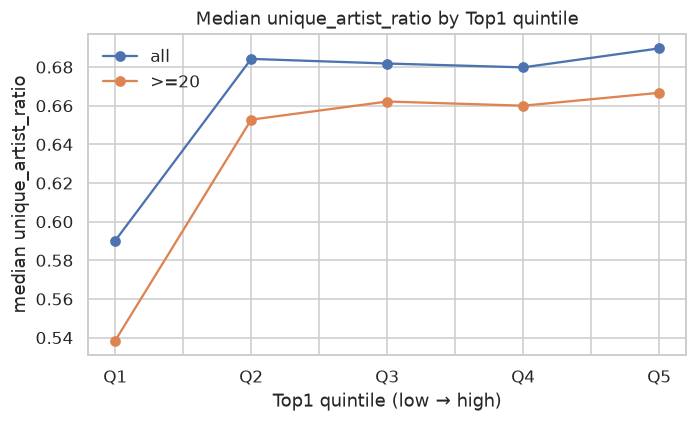

In [24]:
div_all = describe_col(df, "unique_artist_ratio")["p50"].reset_index(drop=True)
div_long = describe_col(df_long, "unique_artist_ratio")["p50"].reset_index(drop=True)
div_cmp = pd.DataFrame({"all": div_all, f">={MIN_TRACKS_SENS}": div_long})
div_cmp.index = [f"Q{i+1}" for i in div_cmp.index]

fig, ax = plt.subplots(figsize=(6.5, 4.0))
div_cmp.plot(marker="o", ax=ax)
ax.set_title("Median unique_artist_ratio by Top1 quintile")
ax.set_xlabel("Top1 quintile (low → high)")
ax.set_ylabel("median unique_artist_ratio")
ax.legend(frameon=False)
fig.tight_layout()

div_cmp.round(3)

## E. (4.5) Artist-centric 확인 — EDA 마지막

4차에서 **Top1 Q1만** Artist diversity가 유독 낮았다.

질문: **그 낮은 diversity가 “특정 Artist를 깊게 담은 Playlist” 때문인가?**

Top1 quintile별 `top_artist_share ≥ 0.3 / 0.5` 비율을 본다. Q1에서만 높으면 Artist-centric long-tail 유형으로 해석할 수 있다.

In [25]:
ARTIST_HEAVY_THRESHOLDS = [0.3, 0.5]

# quintile 순서 (Q1 = Top1 lowest)
q_order = sorted(df["top1_bin"].dropna().unique(), key=lambda x: x.left)
q_labels = {b: f"Q{i+1}" for i, b in enumerate(q_order)}

rows = []
for b in q_order:
    g = df[df["top1_bin"] == b]
    row = {"quintile": q_labels[b], "n": len(g)}
    for t in ARTIST_HEAVY_THRESHOLDS:
        row[f"pct_share_ge_{t:.0%}"] = (g["top_artist_share"] >= t).mean()
    row["median_top_artist_share"] = g["top_artist_share"].median()
    row["median_unique_artist_ratio"] = g["unique_artist_ratio"].median()
    rows.append(row)

artist_centric = pd.DataFrame(rows).set_index("quintile")
artist_centric.round(3)

,n,pct_share_ge_30%,pct_share_ge_50%,median_top_artist_share,median_unique_artist_ratio
quintile,,,,,
Q1,200281,0.223,0.099,0.149,0.590
Q2,201831,0.105,0.035,0.109,0.684
Q3,198053,0.070,0.021,0.100,0.682
Q4,203659,0.068,0.023,0.100,0.680
Q5,196176,0.095,0.040,0.109,0.690


In [26]:
# Q1 = Top1 lowest quintile
q1_bin = q_order[0]
q1 = df[df["top1_bin"] == q1_bin].copy()

if "name" not in q1.columns:
    titles = pd.read_parquet(PROCESSED / "playlist_meta.parquet", columns=["pid", "name"])
    q1 = q1.merge(titles, on="pid", how="left")

sample = (
    q1.nlargest(15, "top_artist_share")[
        ["pid", "name", "num_tracks", Y, "unique_artist_ratio",
         "top_artist_share", "artist_entropy"]
    ]
    .round(3)
)
print("Q1 (Top1 lowest) — top_artist_share 상위 15개 (제목으로 Artist-centric 여부 육안 확인)")
sample

# sensitivity: 20곡 이상 Q1
if len(df_long):
    q1_long = df_long[(df_long[Y] > q1_bin.left) & (df_long[Y] <= q1_bin.right)]
    print(f"\nQ1 n={len(q1):,}  |  Q1 & num_tracks>={MIN_TRACKS_SENS} n={len(q1_long):,}")
    for t in ARTIST_HEAVY_THRESHOLDS:
        all_q1 = (q1["top_artist_share"] >= t).mean()
        long_q1 = (q1_long["top_artist_share"] >= t).mean() if len(q1_long) else float("nan")
        print(f"  share>={t:.0%}:  Q1 all={all_q1:.3f}  Q1 long={long_q1:.3f}")

Q1 (Top1 lowest) — top_artist_share 상위 15개 (제목으로 Artist-centric 여부 육안 확인)

Q1 n=200,281  |  Q1 & num_tracks>=20 n=159,897
  share>=30%:  Q1 all=0.223  Q1 long=0.202
  share>=50%:  Q1 all=0.099  Q1 long=0.093


## 이 노트북에서 결정할 것

**4.5까지 포함 — EDA 종료.**

| 4.5 결과 | 해석 |
|---|---|
| Q1에서 `top_artist_share ≥ 50%` 비율이 Q2~Q5보다 확실히 높음 | 저인기곡 플리 중 **Artist-centric** 유형 존재 → 추천 실험에서 Q1 slice 필수 |
| Q1만 약간 높거나 차이 미미 | Popularity vs Artist composition은 **부분적으로 다른 축** |
| Q1 샘플 제목이 Artist명/컴필레이션 형태 | 스토리에 “Artist fan playlist” 사례 추가 |

**다음 (05):** Raw MPD + Baseline 추천

> **서로 다른 Playlist 구조(Top1 Q1 vs Q5)를 추천 모델이 어떻게 처리하는가?**

- Popularity baseline + Item-CF/BPR 하나
- Recall@K / NDCG@K + 추천 Top1 ratio / Artist diversity
- **Top1 Q1 vs Q5** slice 비교가 핵심